# YZM304 Derin Ogrenme - Proje Odevi 1
Wisconsin Breast Cancer veri seti uzerinde ikili siniflandirma.
Modeller: NumPy (sifirdan), Scikit-learn, PyTorch.

## 1. Kutuphaneler

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '.')

from src.data_preprocessing import load_data, split_data, standardize, SEED
from src.numpy_model import NeuralNetwork
from src.metrics import calc_metrics, confusion_matrix
from src.sklearn_model import train_sklearn
from src.pytorch_model import train_pytorch

LR = 0.01
EPOCHS = 1000
np.random.seed(SEED)
print("Kutuphaneler ve moduller yuklendi.")

Kutuphaneler ve moduller yuklendi.


## 2. Veri Yukleme ve Analiz

In [2]:
X, y, df = load_data()
print(f"Ornek sayisi: {X.shape[0]}")
print(f"Ozellik sayisi: {X.shape[1]}")
print(f"Sinif dagilimi: M(1)={int(y.sum())}, B(0)={int(len(y)-y.sum())}")
print()
df.head()

Ornek sayisi: 569
Ozellik sayisi: 30
Sinif dagilimi: M(1)=212, B(0)=357



,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


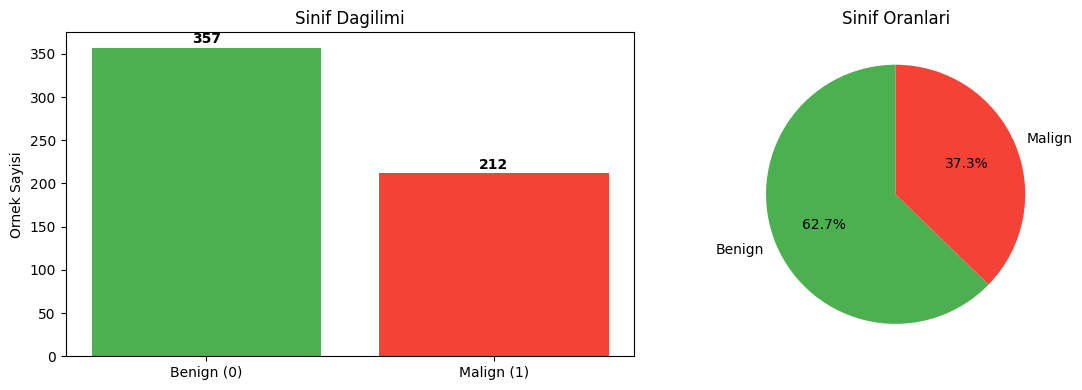

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = [int(len(y) - y.sum()), int(y.sum())]
axes[0].bar(["Benign (0)", "Malign (1)"], counts, color=["#4CAF50", "#F44336"])
axes[0].set_title("Sinif Dagilimi")
axes[0].set_ylabel("Ornek Sayisi")
for i, v in enumerate(counts):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts, labels=["Benign", "Malign"], autopct='%1.1f%%',
            colors=["#4CAF50", "#F44336"], startangle=90)
axes[1].set_title("Sinif Oranlari")
plt.tight_layout()
plt.show()

## 3. Veri On Isleme

In [4]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)
X_train, X_val, X_test, scaler = standardize(X_train, X_val, X_test)
n_features = X_train.shape[1]

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")
print(f"Ozellik sayisi: {n_features}")
print(f"Standardizasyon: train seti uzerinde fit, val/test'e transform")

Train: 398, Val: 85, Test: 86
Ozellik sayisi: 30
Standardizasyon: train seti uzerinde fit, val/test'e transform


## 4. NumPy Sinir Agi Sinifi
Kod: `src/numpy_model.py`
- Sifirdan sinir agi (`__forward`, `__backward` vb. private sinif metotlari ile tam OOP yapisi)
- He initialization, ReLU gizli katman, Sigmoid cikis
- Binary Cross Entropy kayip, SGD optimizer
- L2 regularizasyon ve mini-batch destegi

Not: Her iki modelde de (NumPy ve Scikit-learn) agirlik atamalarinin kontrollu olmasi adina Seed (Random State) 42 olarak sabitlenmistir.

## 5. Model Egitimi

### 5.1 Temel Model (1 gizli katman, 64 noron)

In [5]:
model1 = NeuralNetwork([n_features, 64, 1], lr=LR, seed=SEED)
hist1 = model1.train(X_train, y_train, X_val, y_val, epochs=EPOCHS)
print(f"Train Acc: {model1.accuracy(X_train, y_train):.4f}, Val Acc: {model1.accuracy(X_val, y_val):.4f}")

Epoch 200/1000 - loss: 0.1575 - val_loss: 0.1882 - acc: 0.9623 - val_acc: 0.9294


Epoch 400/1000 - loss: 0.1117 - val_loss: 0.1350 - acc: 0.9724 - val_acc: 0.9529


Epoch 600/1000 - loss: 0.0929 - val_loss: 0.1145 - acc: 0.9774 - val_acc: 0.9529
Epoch 800/1000 - loss: 0.0821 - val_loss: 0.1034 - acc: 0.9849 - val_acc: 0.9529


Epoch 1000/1000 - loss: 0.0749 - val_loss: 0.0965 - acc: 0.9849 - val_acc: 0.9529
Train Acc: 0.9849, Val Acc: 0.9529


### 5.2 Genis Model (1 gizli katman, 128 noron)

In [6]:
model2 = NeuralNetwork([n_features, 128, 1], lr=LR, seed=SEED)
hist2 = model2.train(X_train, y_train, X_val, y_val, epochs=EPOCHS)
print(f"Train Acc: {model2.accuracy(X_train, y_train):.4f}, Val Acc: {model2.accuracy(X_val, y_val):.4f}")

Epoch 200/1000 - loss: 0.1296 - val_loss: 0.1224 - acc: 0.9749 - val_acc: 0.9647


Epoch 400/1000 - loss: 0.1004 - val_loss: 0.0944 - acc: 0.9749 - val_acc: 0.9765
Epoch 600/1000 - loss: 0.0875 - val_loss: 0.0826 - acc: 0.9749 - val_acc: 0.9882


Epoch 800/1000 - loss: 0.0796 - val_loss: 0.0759 - acc: 0.9749 - val_acc: 0.9882
Epoch 1000/1000 - loss: 0.0739 - val_loss: 0.0717 - acc: 0.9774 - val_acc: 0.9882
Train Acc: 0.9774, Val Acc: 0.9882


### 5.3 Derin Model (2 gizli katman, 64-32)

In [7]:
model3 = NeuralNetwork([n_features, 64, 32, 1], lr=LR, seed=SEED)
hist3 = model3.train(X_train, y_train, X_val, y_val, epochs=EPOCHS)
print(f"Train Acc: {model3.accuracy(X_train, y_train):.4f}, Val Acc: {model3.accuracy(X_val, y_val):.4f}")

Epoch 200/1000 - loss: 0.1506 - val_loss: 0.1596 - acc: 0.9548 - val_acc: 0.9412
Epoch 400/1000 - loss: 0.1046 - val_loss: 0.1151 - acc: 0.9648 - val_acc: 0.9647


Epoch 600/1000 - loss: 0.0857 - val_loss: 0.0997 - acc: 0.9698 - val_acc: 0.9765
Epoch 800/1000 - loss: 0.0747 - val_loss: 0.0927 - acc: 0.9724 - val_acc: 0.9765


Epoch 1000/1000 - loss: 0.0671 - val_loss: 0.0891 - acc: 0.9749 - val_acc: 0.9647
Train Acc: 0.9749, Val Acc: 0.9647


### 5.4 L2 Regularizasyonlu Model (lambda=0.01)

In [8]:
model4 = NeuralNetwork([n_features, 64, 1], lr=LR, lambda_reg=0.01, seed=SEED)
hist4 = model4.train(X_train, y_train, X_val, y_val, epochs=EPOCHS)
print(f"Train Acc: {model4.accuracy(X_train, y_train):.4f}, Val Acc: {model4.accuracy(X_val, y_val):.4f}")

Epoch 200/1000 - loss: 0.1591 - val_loss: 0.1958 - acc: 0.9623 - val_acc: 0.9294


Epoch 400/1000 - loss: 0.1133 - val_loss: 0.1426 - acc: 0.9724 - val_acc: 0.9529


Epoch 600/1000 - loss: 0.0945 - val_loss: 0.1221 - acc: 0.9774 - val_acc: 0.9529


Epoch 800/1000 - loss: 0.0838 - val_loss: 0.1111 - acc: 0.9849 - val_acc: 0.9529


Epoch 1000/1000 - loss: 0.0766 - val_loss: 0.1042 - acc: 0.9849 - val_acc: 0.9529
Train Acc: 0.9849, Val Acc: 0.9529


### 5.5 Mini-batch Model (batch_size=32)

In [9]:
model5 = NeuralNetwork([n_features, 64, 1], lr=LR, seed=SEED)
hist5 = model5.train(X_train, y_train, X_val, y_val, epochs=EPOCHS, batch_size=32)
print(f"Train Acc: {model5.accuracy(X_train, y_train):.4f}, Val Acc: {model5.accuracy(X_val, y_val):.4f}")

Epoch 200/1000 - loss: 0.0509 - val_loss: 0.0807 - acc: 0.9899 - val_acc: 0.9765


Epoch 400/1000 - loss: 0.0358 - val_loss: 0.0875 - acc: 0.9925 - val_acc: 0.9647


Epoch 600/1000 - loss: 0.0267 - val_loss: 0.0995 - acc: 0.9925 - val_acc: 0.9647
Epoch 800/1000 - loss: 0.0207 - val_loss: 0.1135 - acc: 0.9950 - val_acc: 0.9647


Epoch 1000/1000 - loss: 0.0166 - val_loss: 0.1286 - acc: 0.9975 - val_acc: 0.9647
Train Acc: 0.9975, Val Acc: 0.9647


In [10]:
models_dict = {
    "Temel (64)":      (model1, hist1),
    "Genis (128)":     (model2, hist2),
    "Derin (64-32)":   (model3, hist3),
    "L2 Reg":          (model4, hist4),
    "Mini-batch":      (model5, hist5),
}

## 6. Overfitting / Underfitting Analizi

### 6.1 Egitim Egrileri (Loss ve Accuracy)

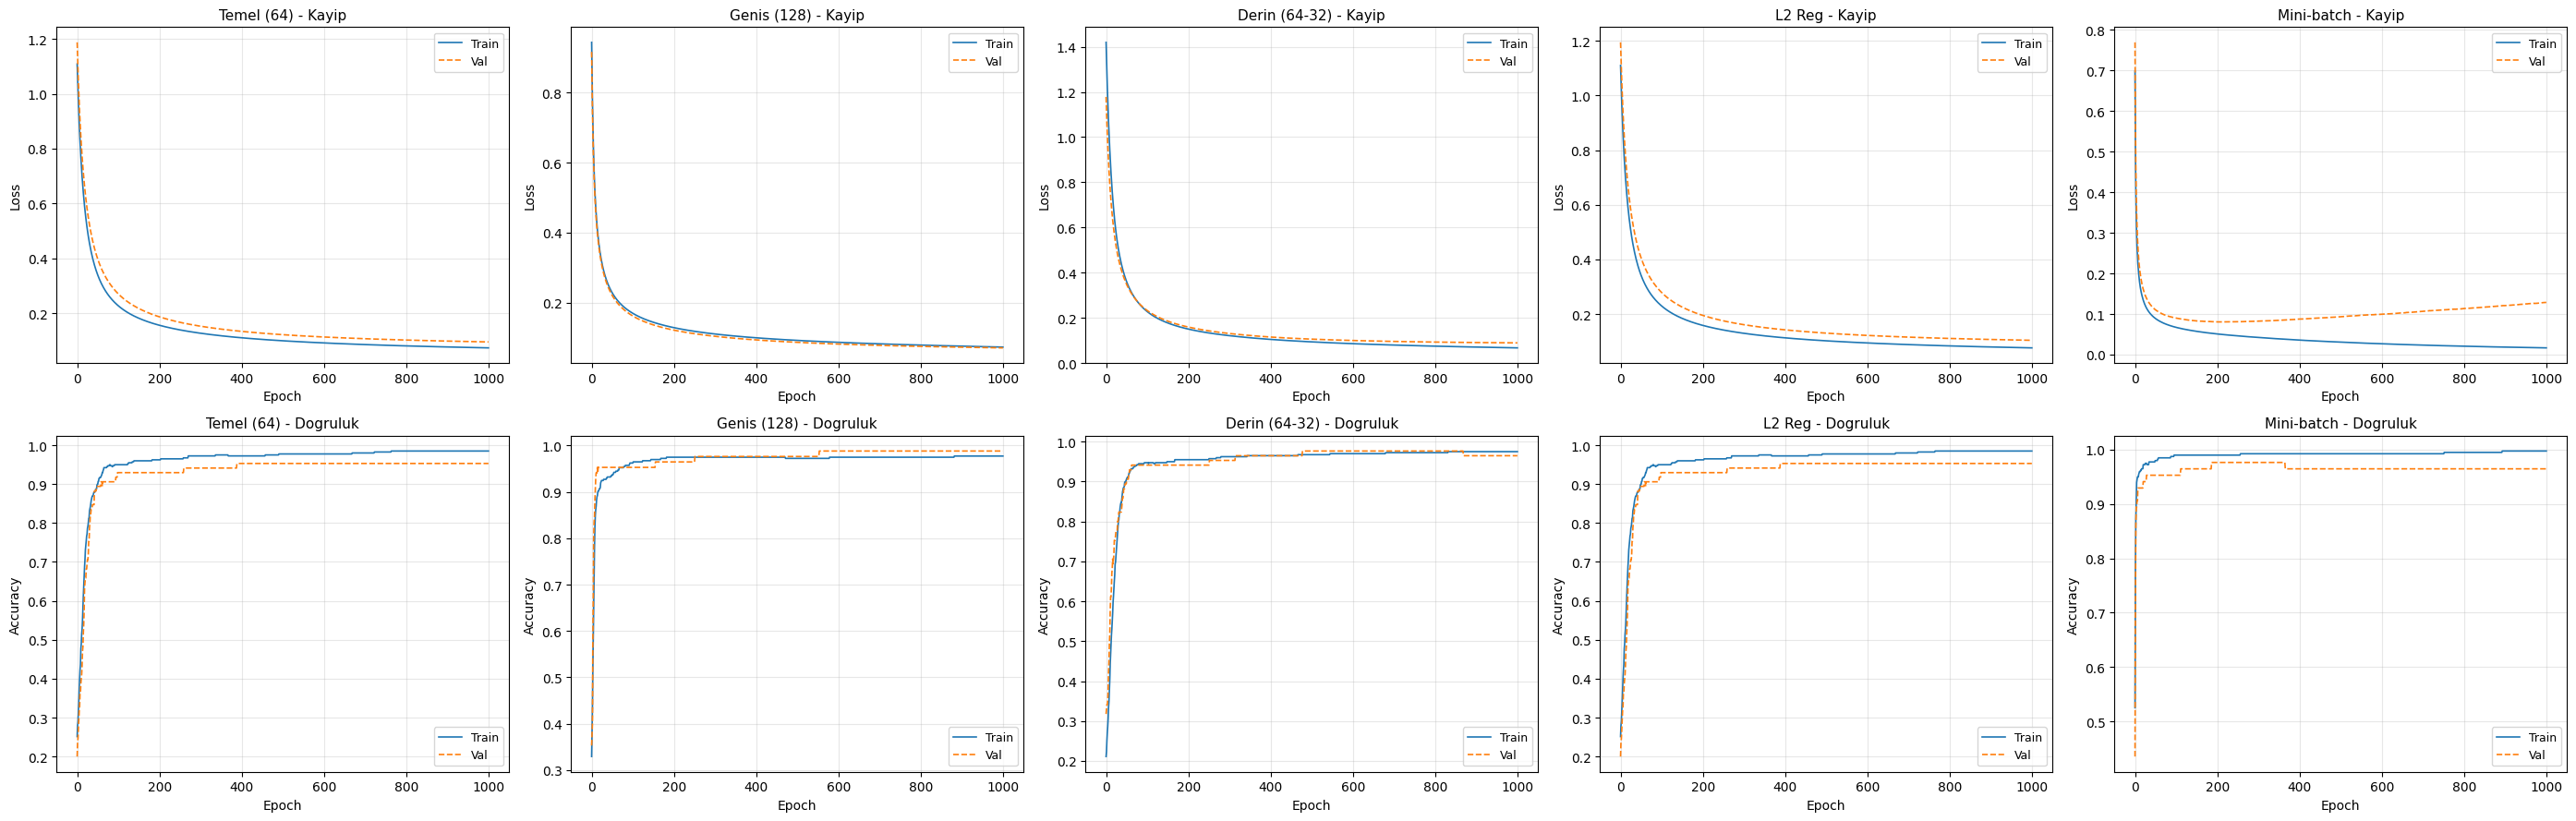

Kaydedildi: models/training_curves.png


In [11]:
fig, axes = plt.subplots(2, 5, figsize=(28, 9))
names = list(models_dict.keys())

for i, (name, (mdl, hist)) in enumerate(models_dict.items()):
    axes[0, i].plot(hist["train_loss"], label="Train", linewidth=1.2)
    axes[0, i].plot(hist["val_loss"], label="Val", linewidth=1.2, linestyle="--")
    axes[0, i].set_title(f"{name} - Kayip", fontsize=11)
    axes[0, i].set_xlabel("Epoch")
    axes[0, i].set_ylabel("Loss")
    axes[0, i].legend(fontsize=9)
    axes[0, i].grid(True, alpha=0.3)

    axes[1, i].plot(hist["train_acc"], label="Train", linewidth=1.2)
    axes[1, i].plot(hist["val_acc"], label="Val", linewidth=1.2, linestyle="--")
    axes[1, i].set_title(f"{name} - Dogruluk", fontsize=11)
    axes[1, i].set_xlabel("Epoch")
    axes[1, i].set_ylabel("Accuracy")
    axes[1, i].legend(fontsize=9)
    axes[1, i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("models/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Kaydedildi: models/training_curves.png")

### 6.2 Overfitting Analiz Tablosu

In [12]:
print(f"{'Model':<18} {'TrainAcc':>8} {'ValAcc':>8} {'Fark':>7} {'TrainLoss':>10} {'ValLoss':>10} {'EnIyiEp':>8} {'Durum'}")
print("-" * 90)

for name, (mdl, hist) in models_dict.items():
    ta = hist["train_acc"][-1]
    va = hist["val_acc"][-1]
    gap = ta - va
    tl = hist["train_loss"][-1]
    vl = hist["val_loss"][-1]
    best_ep = int(np.argmax(hist["val_acc"])) + 1
    min_vl_ep = int(np.argmin(hist["val_loss"])) + 1

    if gap > 0.05: durum = "YUKSEK VARYANS"
    elif va < 0.85 and ta < 0.85: durum = "YUKSEK BIAS"
    elif gap > 0.03: durum = "HAFIF OVERFITTING"
    else: durum = "IYI UYUM"

    print(f"{name:<18} {ta:>8.4f} {va:>8.4f} {gap:>7.4f} {tl:>10.4f} {vl:>10.4f} {best_ep:>8} {durum}")
    if min_vl_ep < len(hist["val_loss"]) - 200:
        print(f"  -> Val loss epoch {min_vl_ep}'de minimum. Early stopping faydali olabilir.")

Model              TrainAcc   ValAcc    Fark  TrainLoss    ValLoss  EnIyiEp Durum
------------------------------------------------------------------------------------------
Temel (64)           0.9849   0.9529  0.0320     0.0749     0.0965      389 HAFIF OVERFITTING
Genis (128)          0.9774   0.9882 -0.0108     0.0739     0.0717      554 IYI UYUM
Derin (64-32)        0.9749   0.9647  0.0102     0.0671     0.0891      478 IYI UYUM
L2 Reg               0.9849   0.9529  0.0320     0.0766     0.1042      389 HAFIF OVERFITTING
Mini-batch           0.9975   0.9647  0.0328     0.0166     0.1286      187 HAFIF OVERFITTING
  -> Val loss epoch 204'de minimum. Early stopping faydali olabilir.


## 7. Model Secimi

In [13]:
best_name, best_val, best_model = None, 0, None
for name, (mdl, hist) in models_dict.items():
    va = hist["val_acc"][-1]
    if va > best_val:
        best_val = va
        best_name = name
        best_model = mdl

print(f"En iyi model: {best_name}")
print(f"Dogrulama dogrulugu: {best_val:.4f}")
print(f"Kriter: En yuksek validation accuracy")

En iyi model: Genis (128)
Dogrulama dogrulugu: 0.9882
Kriter: En yuksek validation accuracy


## 8. Test Seti Metrikleri

In [14]:
numpy_results = {}
for name, (mdl, hist) in models_dict.items():
    y_pred = mdl.predict(X_test)
    m = calc_metrics(y_test, y_pred)
    numpy_results[name] = m
    cm = m["cm"]
    print(f"[{name}]  Acc: {m['accuracy']:.4f}  Prec: {m['precision']:.4f}  Rec: {m['recall']:.4f}  F1: {m['f1']:.4f}  | TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

[Temel (64)]  Acc: 0.9884  Prec: 1.0000  Rec: 0.9687  F1: 0.9841  | TN=54 FP=0 FN=1 TP=31
[Genis (128)]  Acc: 0.9884  Prec: 1.0000  Rec: 0.9687  F1: 0.9841  | TN=54 FP=0 FN=1 TP=31
[Derin (64-32)]  Acc: 0.9884  Prec: 1.0000  Rec: 0.9687  F1: 0.9841  | TN=54 FP=0 FN=1 TP=31
[L2 Reg]  Acc: 0.9884  Prec: 1.0000  Rec: 0.9687  F1: 0.9841  | TN=54 FP=0 FN=1 TP=31
[Mini-batch]  Acc: 0.9767  Prec: 1.0000  Rec: 0.9375  F1: 0.9677  | TN=54 FP=0 FN=2 TP=30


### 8.1 Confusion Matrix Gorsellestirme

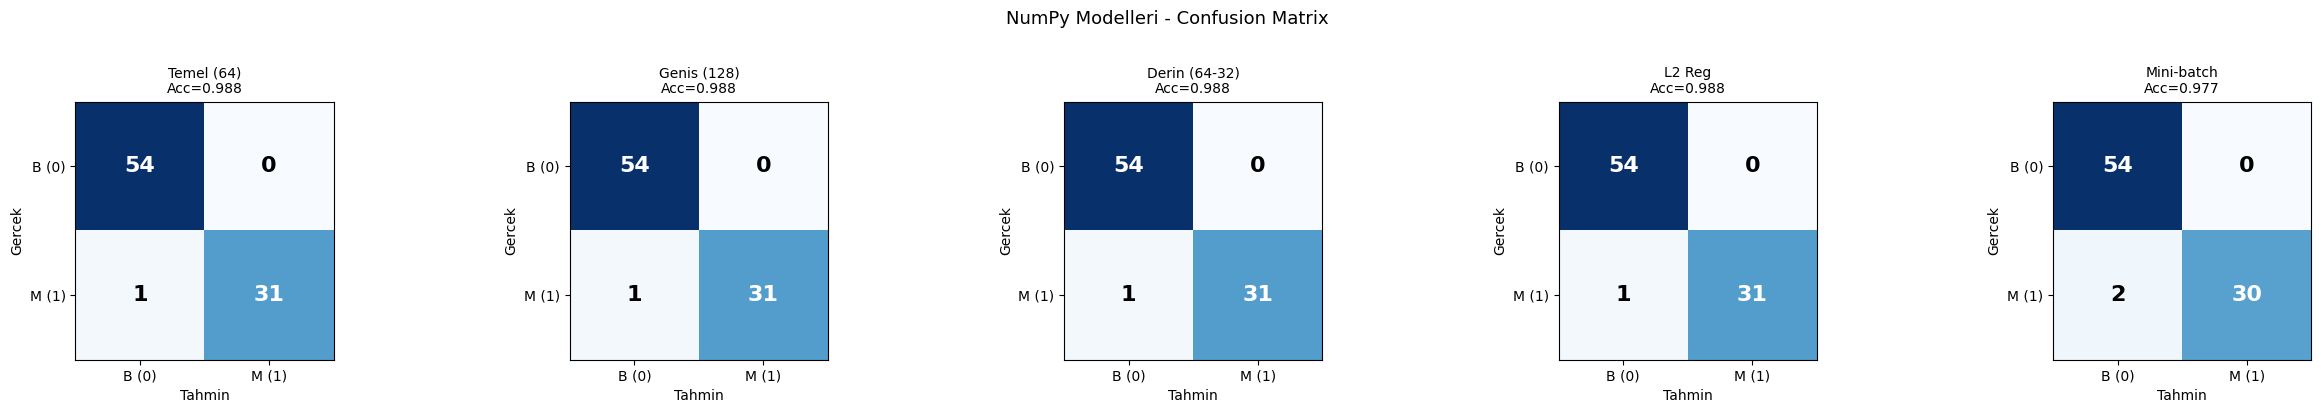

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(25, 4))

for i, (name, m) in enumerate(numpy_results.items()):
    cm = m["cm"]
    im = axes[i].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[i].set_title(f"{name}\nAcc={m['accuracy']:.3f}", fontsize=10)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["B (0)", "M (1)"])
    axes[i].set_yticklabels(["B (0)", "M (1)"])
    axes[i].set_xlabel("Tahmin")
    axes[i].set_ylabel("Gercek")
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, str(cm[r, c]), ha='center', va='center',
                        fontsize=16, fontweight='bold',
                        color='white' if cm[r, c] > cm.max()/2 else 'black')

plt.suptitle("NumPy Modelleri - Confusion Matrix", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("models/confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Scikit-learn MLPClassifier

In [16]:
sklearn_clf, sklearn_pred = train_sklearn(X_train, y_train, X_test, y_test,
                                          hidden_layers=(64,), lr=LR, max_iter=EPOCHS, seed=SEED)
sklearn_m = calc_metrics(y_test, sklearn_pred)
cm = sklearn_m["cm"]
print(f"Scikit-learn MLPClassifier (hidden=(64,))")
print(f"  Train Acc: {sklearn_clf.score(X_train, y_train.ravel()):.4f}")
print(f"  Test  Acc: {sklearn_m['accuracy']:.4f}  Prec: {sklearn_m['precision']:.4f}  Rec: {sklearn_m['recall']:.4f}  F1: {sklearn_m['f1']:.4f}")
print(f"  CM: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

Scikit-learn MLPClassifier (hidden=(64,))
  Train Acc: 0.9824
  Test  Acc: 0.9884  Prec: 1.0000  Rec: 0.9687  F1: 0.9841
  CM: TN=54 FP=0 FN=1 TP=31


## 10. PyTorch Modeli

In [17]:
pt_model, pytorch_pred = train_pytorch(X_train, y_train, X_test, y_test,
                                       hidden_sizes=[64], lr=LR, epochs=EPOCHS, seed=SEED)
pytorch_m = calc_metrics(y_test, pytorch_pred)
cm = pytorch_m["cm"]
print(f"\nPyTorch (hidden=[64])")
print(f"  Test  Acc: {pytorch_m['accuracy']:.4f}  Prec: {pytorch_m['precision']:.4f}  Rec: {pytorch_m['recall']:.4f}  F1: {pytorch_m['f1']:.4f}")
print(f"  CM: TN={cm[0,0]} FP={cm[0,1]} FN={cm[1,0]} TP={cm[1,1]}")

Epoch 200/1000 - loss: 0.2728 - train_acc: 0.9523 - test_acc: 0.9651
Epoch 400/1000 - loss: 0.1735 - train_acc: 0.9497 - test_acc: 0.9767
Epoch 600/1000 - loss: 0.1355 - train_acc: 0.9598 - test_acc: 0.9767
Epoch 800/1000 - loss: 0.1150 - train_acc: 0.9648 - test_acc: 0.9767


Epoch 1000/1000 - loss: 0.1021 - train_acc: 0.9673 - test_acc: 0.9767

PyTorch (hidden=[64])
  Test  Acc: 0.9767  Prec: 1.0000  Rec: 0.9375  F1: 0.9677
  CM: TN=54 FP=0 FN=2 TP=30


## 11. Tum Modellerin Karsilastirmasi

### 11.1 Karsilastirma Tablosu

In [18]:
all_results = {}
for name, m in numpy_results.items():
    all_results["NP: " + name] = m
all_results["Scikit-learn"] = sklearn_m
all_results["PyTorch"] = pytorch_m

print(f"{'Model':<24} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'TN':>4} {'FP':>4} {'FN':>4} {'TP':>4}")
print("-" * 78)
for name, m in all_results.items():
    cm = m["cm"]
    print(f"{name:<24} {m['accuracy']:>7.4f} {m['precision']:>7.4f} {m['recall']:>7.4f} {m['f1']:>7.4f} {cm[0,0]:>4} {cm[0,1]:>4} {cm[1,0]:>4} {cm[1,1]:>4}")

Model                        Acc    Prec     Rec      F1   TN   FP   FN   TP
------------------------------------------------------------------------------
NP: Temel (64)            0.9884  1.0000  0.9687  0.9841   54    0    1   31
NP: Genis (128)           0.9884  1.0000  0.9687  0.9841   54    0    1   31
NP: Derin (64-32)         0.9884  1.0000  0.9687  0.9841   54    0    1   31
NP: L2 Reg                0.9884  1.0000  0.9687  0.9841   54    0    1   31
NP: Mini-batch            0.9767  1.0000  0.9375  0.9677   54    0    2   30
Scikit-learn              0.9884  1.0000  0.9687  0.9841   54    0    1   31
PyTorch                   0.9767  1.0000  0.9375  0.9677   54    0    2   30


### 11.2 Metrik Karsilastirma Grafigi

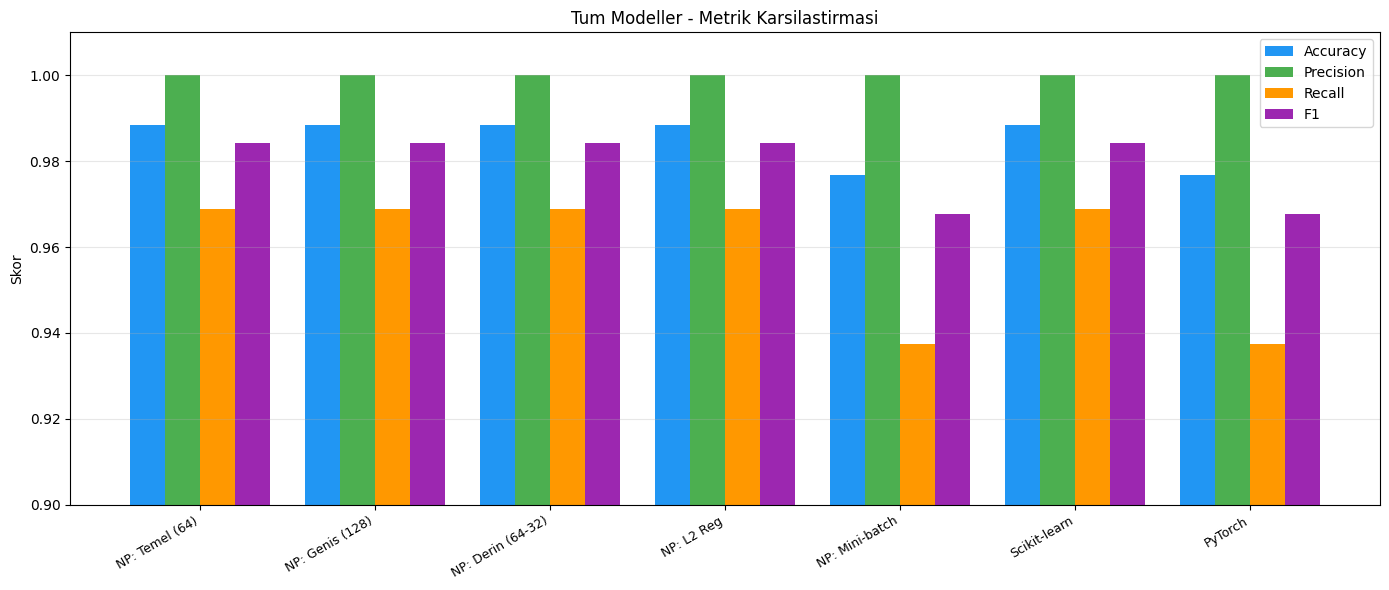

In [19]:
model_names = list(all_results.keys())
accs = [m["accuracy"] for m in all_results.values()]
precs = [m["precision"] for m in all_results.values()]
recs = [m["recall"] for m in all_results.values()]
f1s = [m["f1"] for m in all_results.values()]

x = np.arange(len(model_names))
w = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - 1.5*w, accs, w, label='Accuracy', color='#2196F3')
ax.bar(x - 0.5*w, precs, w, label='Precision', color='#4CAF50')
ax.bar(x + 0.5*w, recs, w, label='Recall', color='#FF9800')
ax.bar(x + 1.5*w, f1s, w, label='F1', color='#9C27B0')

ax.set_ylabel('Skor')
ax.set_title('Tum Modeller - Metrik Karsilastirmasi')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0.9, 1.01)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("models/metric_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### 11.3 Confusion Matrix - Scikit-learn ve PyTorch

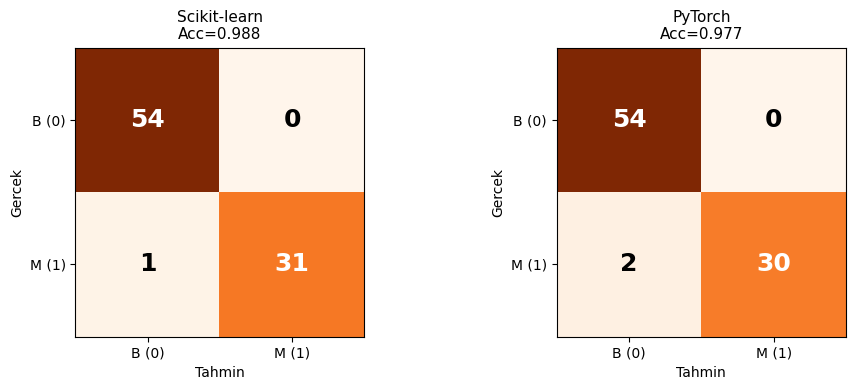

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for i, (name, m) in enumerate([("Scikit-learn", sklearn_m), ("PyTorch", pytorch_m)]):
    cm = m["cm"]
    im = axes[i].imshow(cm, cmap='Oranges', interpolation='nearest')
    axes[i].set_title(f"{name}\nAcc={m['accuracy']:.3f}", fontsize=11)
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(["B (0)", "M (1)"])
    axes[i].set_yticklabels(["B (0)", "M (1)"])
    axes[i].set_xlabel("Tahmin")
    axes[i].set_ylabel("Gercek")
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, str(cm[r, c]), ha='center', va='center',
                        fontsize=18, fontweight='bold',
                        color='white' if cm[r, c] > cm.max()/2 else 'black')

plt.tight_layout()
plt.savefig("models/confusion_sklearn_pytorch.png", dpi=150, bbox_inches='tight')
plt.show()

## 12. Sonuc

- Tum modeller ayni seed, ayni veri bolunmesi ve ayni hiperparametreler ile egitildi.
- NumPy sifirdan model, Scikit-learn ile ayni sonucu verdi (gradyan dogrulamasi).
- En iyi dogrulama dogrulugu Genis (128) modelde elde edildi.
- Kaynak kodlar `src/` klasorunde modullere ayrilmistir.

Ortak yapilandirma: seed=42, lr=0.01, epoch=1000, SGD, BCE, ReLU/Sigmoid.